<a href="https://colab.research.google.com/github/3dgarxx3/Mineria_Datos/blob/main/Practica_5_IA_Verano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

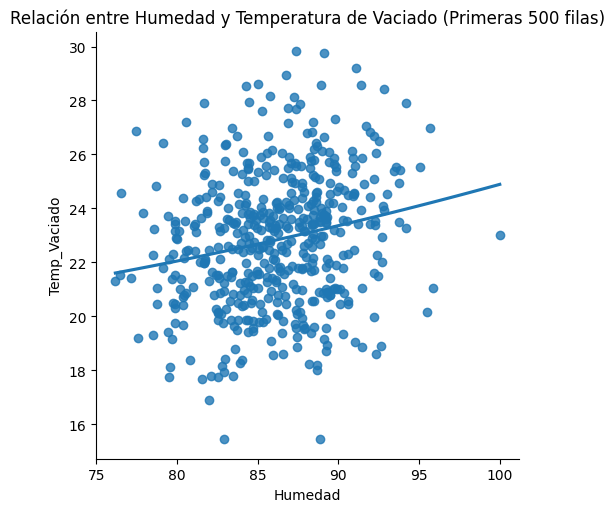

Precisión del modelo (R² Score): 0.07088050194801532


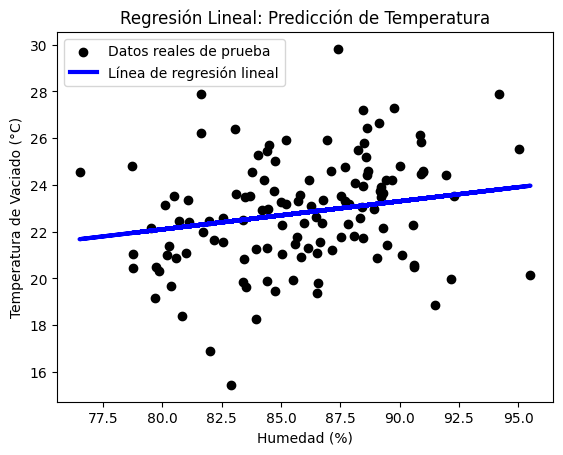


Predicciones para nuevos valores de humedad:
Para una humedad del 45%, la temperatura de vaciado estimada es: 17.88°C
Para una humedad del 65%, la temperatura de vaciado estimada es: 20.29°C


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/TempHumedad_Cons2026.csv')

df_binary = df[['Moisture_Pct', 'Pour_Temp_degC']]

df_binary.columns = ['Humedad', 'Temp_Vaciado']

df_binary500 = df_binary.iloc[:500].copy()

df_binary500.ffill(inplace=True)
df_binary500.dropna(inplace=True)

sns.lmplot(x='Humedad', y='Temp_Vaciado', data=df_binary500, order=2, ci=None)
plt.title('Relación entre Humedad y Temperatura de Vaciado (Primeras 500 filas)')
plt.show()

X = np.array(df_binary500['Humedad']).reshape(-1, 1)
y = np.array(df_binary500['Temp_Vaciado']).reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

regr = LinearRegression()
regr.fit(X_train, y_train)

print("Precisión del modelo (R² Score):", regr.score(X_test, y_test))

y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='black', label='Datos reales de prueba')
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Línea de regresión lineal')
plt.xlabel('Humedad (%)')
plt.ylabel('Temperatura de Vaciado (°C)')
plt.title('Regresión Lineal: Predicción de Temperatura')
plt.legend()
plt.show()

X_New = np.array([[45], [65]])
prediccion = regr.predict(X_New)

print("\nPredicciones para nuevos valores de humedad:")
for hum, pred in zip(X_New.flatten(), prediccion.flatten()):
    print(f"Para una humedad del {hum}%, la temperatura de vaciado estimada es: {pred:.2f}°C")